# Prediksi Harga Rumah — Jabodetabek (Versi Perbaikan + EDA)

Model ini memprediksi harga rumah HANYA berdasarkan 7 fitur berikut:
- Luas tanah (`land_size_m2`)
- Luas bangunan (`building_size_m2`)
- Jumlah kamar tidur (`bedrooms`)
- Jumlah kamar mandi (`bathrooms`)
- Jumlah lantai (`floors`)
- Garasi (`garages`)
- Kota (`city`)

**Perbaikan dari notebook sebelumnya:**
1. ❌ Menghapus `price_per_m2` sebagai fitur (ini penyebab *data leakage*, karena dihitung dari target `price_in_rp`)
2. ❌ Menghapus semua fitur di luar 7 fitur yang diminta (`district`, `facilities`, `lat`, `long`, `certificate`, dll)
3. ✅ Encoding kategorikal (`city`) sekarang wajar — tidak meledak jadi ribuan kolom
4. ✅ Scaler ikut disimpan (untuk konsistensi, meski RandomForest tidak wajib butuh scaling)
5. ✅ Ditambahkan bagian **EDA (Exploratory Data Analysis)** khusus untuk 7 fitur yang dipakai
6. ✅ Ditambahkan fungsi prediksi contoh, supaya kamu bisa cek langsung apakah perubahan fitur benar-benar mengubah harga prediksi


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Load Data

In [2]:
df = pd.read_csv('jabodetabek_house_price.csv')
print("Shape awal:", df.shape)
df.head()


Shape awal: (3553, 27)


,url,price_in_rp,title,address,district,city,lat,long,facilities,property_type,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,https://www.rumah123.com/properti/bekasi/hos11...,2.990000e+09,Rumah cantik Sumarecon Bekasi\nLingkungan asri...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Tempat Jemuran, Jalur Telepon, Taman, Taman",rumah,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,https://www.rumah123.com/properti/bekasi/hos10...,1.270000e+09,"Rumah Kekinian, Magenta Summarecon Bekasi","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,Taman,rumah,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,https://www.rumah123.com/properti/bekasi/hos10...,1.950000e+09,Rumah Cantik 2 Lantai Cluster Bluebell Summare...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Masjid, Taman,...",rumah,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,https://www.rumah123.com/properti/bekasi/hos10...,3.300000e+09,Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jalur Telepon, Jogging Track, Track Lari, K...",rumah,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,https://www.rumah123.com/properti/bekasi/hos10...,4.500000e+09,"Rumah Hoek di Cluster Maple Summarecon Bekasi,...","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Taman, Jalur Te...",rumah,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


## 2. Pilih HANYA 7 fitur yang diminta + target

Ini langkah kunci yang berbeda dari notebook sebelumnya. Kita tidak memakai semua
kolom di dataset, hanya kolom yang relevan dengan permintaan.


In [3]:
FITUR_TERPAKAI = [
    'land_size_m2',
    'building_size_m2',
    'bedrooms',
    'bathrooms',
    'floors',
    'garages',
    'city'
]

TARGET = 'price_in_rp'

df_model = df[FITUR_TERPAKAI + [TARGET]].copy()
print("Shape setelah seleksi fitur:", df_model.shape)
df_model.head()


Shape setelah seleksi fitur: (3553, 8)


,land_size_m2,building_size_m2,bedrooms,bathrooms,floors,garages,city,price_in_rp
0,239.0,272.0,4.0,4.0,2.0,0.0,Bekasi,2.990000e+09
1,55.0,69.0,3.0,2.0,2.0,0.0,Bekasi,1.270000e+09
2,119.0,131.0,3.0,3.0,2.0,1.0,Bekasi,1.950000e+09
3,180.0,174.0,3.0,3.0,2.0,2.0,Bekasi,3.300000e+09
4,328.0,196.0,4.0,3.0,2.0,1.0,Bekasi,4.500000e+09


## 3. Cek & Tangani Missing Value

In [4]:
print("===== MISSING VALUE (SEBELUM) =====")
print(df_model.isnull().sum())


===== MISSING VALUE (SEBELUM) =====
land_size_m2         2
building_size_m2     2
bedrooms            34
bathrooms           29
floors               6
garages              0
city                 0
price_in_rp          0
dtype: int64


In [5]:
# Kolom numerik -> isi dengan median
num_cols = ['land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms', 'floors', 'garages']
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Kolom kategorikal (city) -> isi dengan modus
df_model['city'] = df_model['city'].fillna(df_model['city'].mode()[0])

print("===== MISSING VALUE (SESUDAH) =====")
print(df_model.isnull().sum())


===== MISSING VALUE (SESUDAH) =====
land_size_m2        0
building_size_m2    0
bedrooms            0
bathrooms           0
floors              0
garages             0
city                0
price_in_rp         0
dtype: int64


## 4. Hapus Duplikat & Outlier Ekstrem pada Target

In [6]:
print("Duplikat:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates()

# Harga rumah biasanya sangat skewed (ada rumah mewah bernilai puluhan miliar).
# Kita buang outlier ekstrem memakai metode IQR supaya model tidak "ditarik"
# oleh segelintir rumah termahal.
Q1 = df_model[TARGET].quantile(0.25)
Q3 = df_model[TARGET].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

before = df_model.shape[0]
df_model = df_model[(df_model[TARGET] >= batas_bawah) & (df_model[TARGET] <= batas_atas)]
print(f"Baris dibuang karena outlier: {before - df_model.shape[0]}")
print("Shape akhir:", df_model.shape)


Duplikat: 787
Baris dibuang karena outlier: 314
Shape akhir: (2452, 8)


## 5. EDA (Exploratory Data Analysis)

Bagian ini murni untuk memahami data — tidak mengubah dataset. Semua eksplorasi
di bawah hanya menyentuh 7 fitur yang benar-benar dipakai model, supaya tidak
menyesatkan (tidak ada eksplorasi kolom yang nanti tidak dipakai, seperti `facilities`
atau `district` di notebook sebelumnya).


In [7]:
df_model[num_cols + [TARGET]].describe()


,land_size_m2,building_size_m2,bedrooms,bathrooms,floors,garages,price_in_rp
count,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2.452000e+03
mean,152.543230,144.663540,3.125204,2.392741,1.747961,0.590538,2.167140e+09
std,247.342151,123.783335,1.298488,1.186211,0.604701,0.821205,1.883759e+09
min,12.000000,18.000000,1.000000,1.000000,1.000000,0.000000,4.200000e+07
25%,72.000000,63.000000,2.000000,2.000000,1.000000,0.000000,7.820000e+08
50%,105.000000,108.000000,3.000000,2.000000,2.000000,0.000000,1.450000e+09
75%,162.000000,188.250000,4.000000,3.000000,2.000000,1.000000,3.000000e+09
max,4704.000000,2000.000000,37.000000,16.000000,4.000000,10.000000,8.900000e+09


### 5.1 Distribusi Harga Rumah (Target)

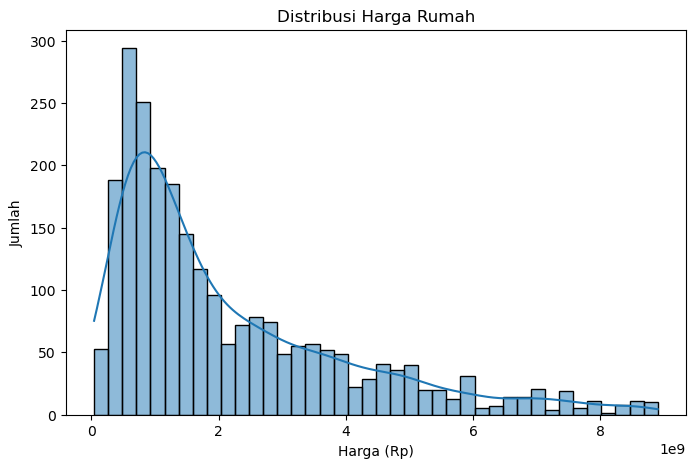

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_model[TARGET], bins=40, kde=True)
plt.title("Distribusi Harga Rumah")
plt.xlabel("Harga (Rp)")
plt.ylabel("Jumlah")
plt.show()


### 5.2 Distribusi Tiap Fitur Numerik

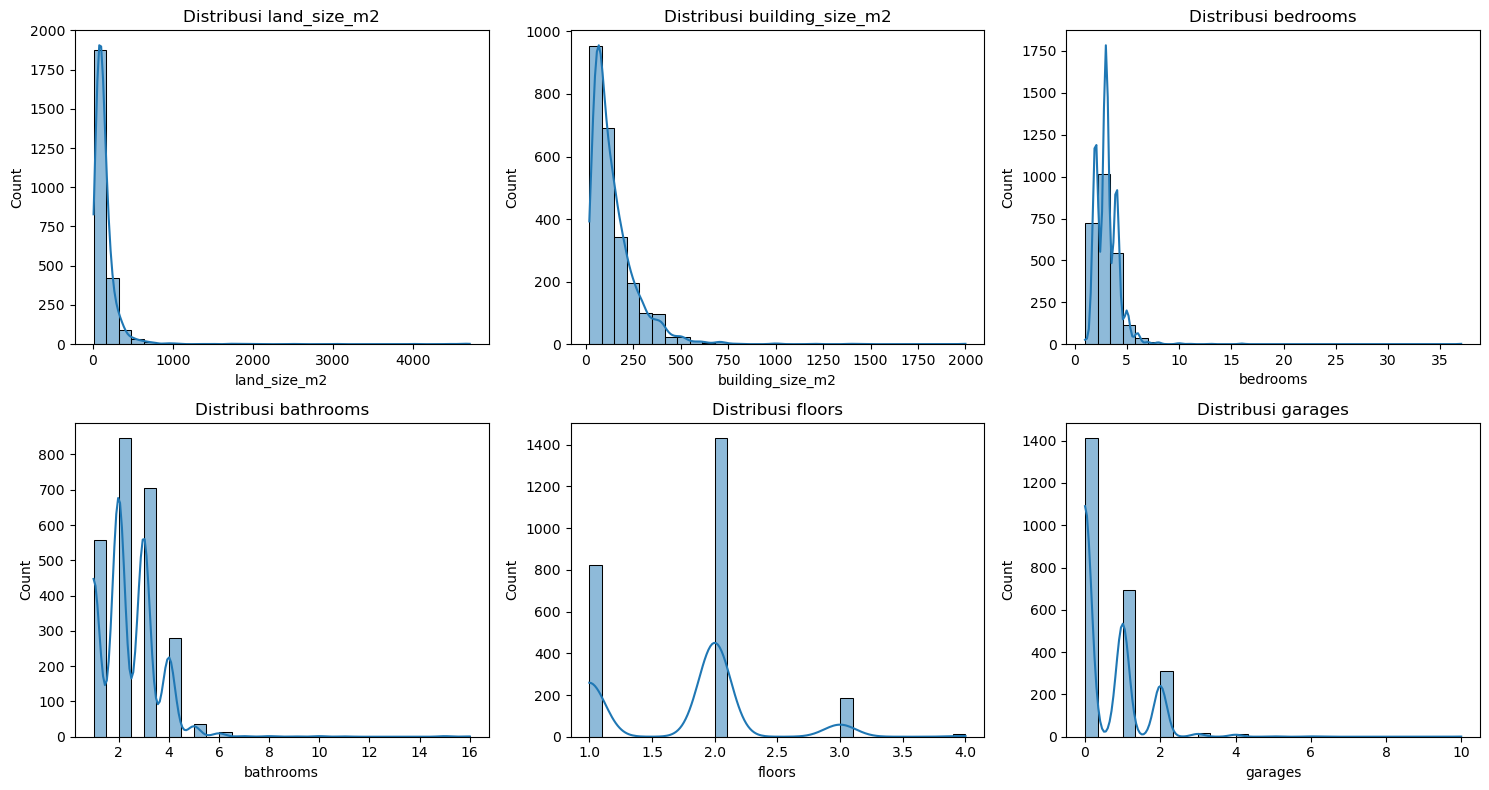

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribusi {col}")

plt.tight_layout()
plt.show()


### 5.3 Hubungan Tiap Fitur Numerik terhadap Harga

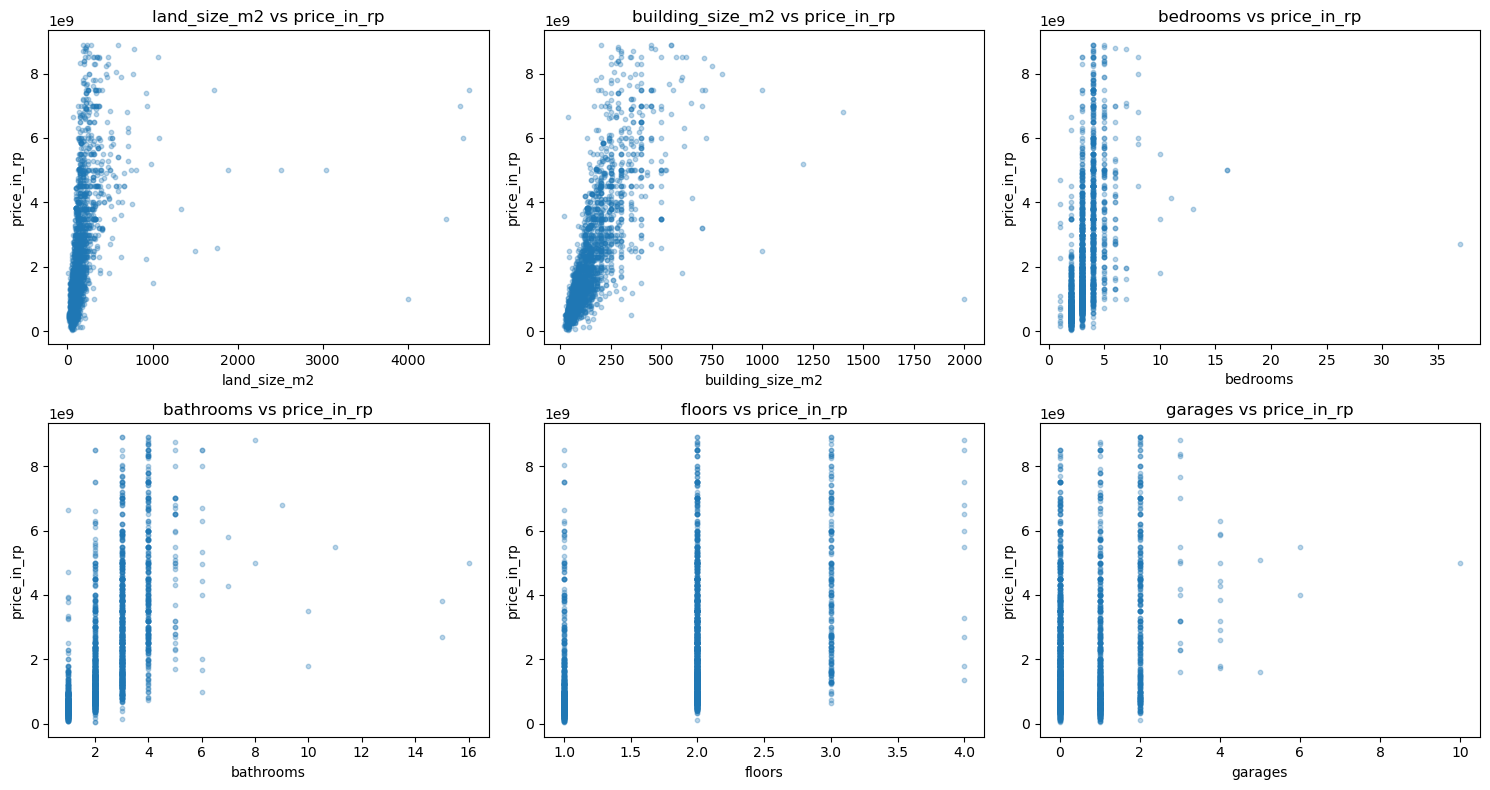

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df_model[col], df_model[TARGET], alpha=0.3, s=10)
    axes[i].set_title(f"{col} vs {TARGET}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

plt.tight_layout()
plt.show()


### 5.4 Rata-rata Harga per Kota

city
Jakarta Utara      4.680614e+09
Jakarta Selatan    3.977684e+09
Jakarta Barat      3.489446e+09
Tangerang          2.761013e+09
Jakarta Pusat      2.255267e+09
Jakarta Timur      1.898532e+09
Bogor              1.853363e+09
Bekasi             1.320996e+09
Depok              1.267483e+09
Name: price_in_rp, dtype: float64


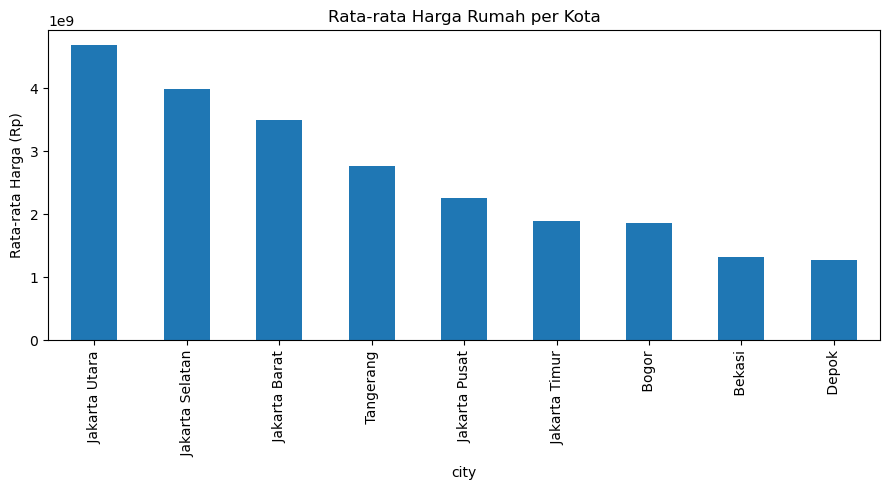

In [11]:
harga_per_kota = df_model.groupby('city')[TARGET].mean().sort_values(ascending=False)
print(harga_per_kota)

plt.figure(figsize=(9,5))
harga_per_kota.plot(kind='bar')
plt.title("Rata-rata Harga Rumah per Kota")
plt.ylabel("Rata-rata Harga (Rp)")
plt.tight_layout()
plt.show()


### 5.5 Korelasi Antar Fitur Numerik

Berguna untuk melihat fitur mana yang paling berkorelasi dengan harga, dan
mengecek apakah ada dua fitur yang terlalu mirip satu sama lain (redundant).


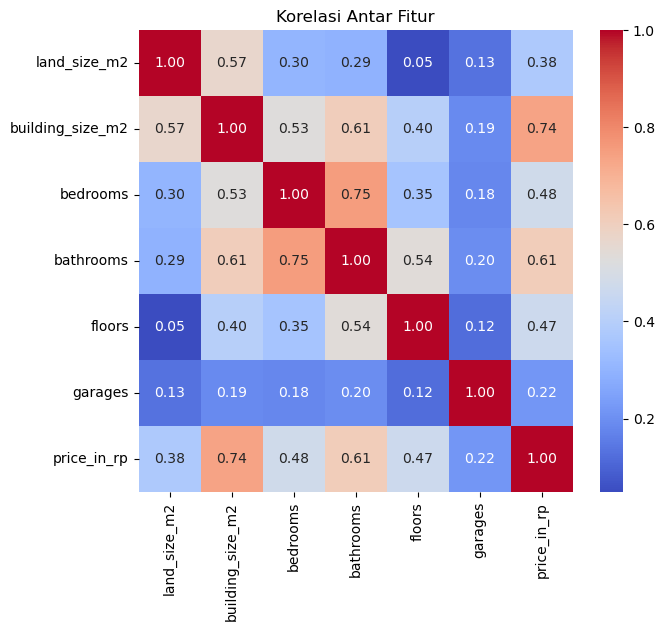

In [12]:
plt.figure(figsize=(7,6))
corr = df_model[num_cols + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antar Fitur")
plt.show()


## 6. Cek Jumlah Kategori Kota (pastikan tidak meledak seperti sebelumnya)

In [13]:
print("Jumlah kota unik:", df_model['city'].nunique())
print(df_model['city'].value_counts())


Jumlah kota unik: 9
city
Tangerang          611
Bogor              553
Bekasi             477
Depok              379
Jakarta Barat      166
Jakarta Selatan    117
Jakarta Timur       77
Jakarta Utara       57
Jakarta Pusat       15
Name: count, dtype: int64


## 7. Encoding Kota

In [14]:
df_encoded = pd.get_dummies(df_model, columns=['city'], drop_first=True)
print("Shape setelah encoding:", df_encoded.shape)
df_encoded.head()


Shape setelah encoding: (2452, 15)


,land_size_m2,building_size_m2,bedrooms,bathrooms,floors,garages,price_in_rp,city_ Bogor,city_ Depok,city_ Jakarta Barat,city_ Jakarta Pusat,city_ Jakarta Selatan,city_ Jakarta Timur,city_ Jakarta Utara,city_ Tangerang
0,239.0,272.0,4.0,4.0,2.0,0.0,2.990000e+09,False,False,False,False,False,False,False,False
1,55.0,69.0,3.0,2.0,2.0,0.0,1.270000e+09,False,False,False,False,False,False,False,False
2,119.0,131.0,3.0,3.0,2.0,1.0,1.950000e+09,False,False,False,False,False,False,False,False
3,180.0,174.0,3.0,3.0,2.0,2.0,3.300000e+09,False,False,False,False,False,False,False,False
4,328.0,196.0,4.0,3.0,2.0,1.0,4.500000e+09,False,False,False,False,False,False,False,False


## 8. Split Feature & Target

**PENTING:** `price_per_m2` TIDAK dibuat di sini. Kita tidak menambahkan fitur apa pun
yang dihitung dari `price_in_rp`, supaya tidak terjadi data leakage.


In [15]:
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDaftar fitur final:")
print(X.columns.tolist())


Shape X: (2452, 14)
Shape y: (2452,)

Daftar fitur final:
['land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms', 'floors', 'garages', 'city_ Bogor', 'city_ Depok', 'city_ Jakarta Barat', 'city_ Jakarta Pusat', 'city_ Jakarta Selatan', 'city_ Jakarta Timur', 'city_ Jakarta Utara', 'city_ Tangerang']


## 9. Split Train/Test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1961, 14)
Test : (491, 14)


## 10. Scaling

RandomForest sebenarnya tidak wajib butuh scaling (ia berbasis pembagian pohon,
bukan jarak/gradient). Di sini scaling tetap dipakai untuk konsistensi dan
supaya kalau nanti diganti model lain (mis. Linear Regression / SVR), pipeline-nya
tidak perlu diubah — **tapi scaler-nya kita simpan**, tidak seperti sebelumnya.


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 11. Training Model

In [18]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,          # dikurangi dari 25 -> mencegah overfitting krn fitur lebih sedikit
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train_scaled, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 12. Simpan Model, Fitur, dan Scaler

In [19]:
joblib.dump(model, 'random_forest_model.pkl')
joblib.dump(X.columns.tolist(), 'fitur_model.pkl')
joblib.dump(scaler, 'scaler.pkl')   # <-- sebelumnya tidak disimpan

print("Model, daftar fitur, dan scaler berhasil disimpan.")


Model, daftar fitur, dan scaler berhasil disimpan.


## 13. Evaluasi Model

In [20]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)


MAE  : 478555537.9766672
RMSE : 747541519.1402817
R2   : 0.8322885373148021


In [21]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Rata-rata CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())


CV R2 scores: [0.80812978 0.76866107 0.79152179 0.76210969 0.84707873]
Rata-rata CV R2: 0.7955002117109842
Std CV R2: 0.030564501197532727


Bandingkan `Rata-rata CV R2` di sini dengan yang sebelumnya (~ -0.003, sangat tidak stabil).
Kalau perbaikan ini berhasil, angka CV seharusnya jauh lebih stabil dan tidak ada fold yang negatif ekstrem.

## 14. Feature Importance

building_size_m2         7.806426e-01
land_size_m2             8.674301e-02
city_ Jakarta Utara      2.354101e-02
city_ Tangerang          1.861816e-02
floors                   1.757450e-02
bathrooms                1.730215e-02
garages                  1.227400e-02
city_ Jakarta Selatan    1.138669e-02
bedrooms                 1.115891e-02
city_ Jakarta Barat      1.021651e-02
city_ Bogor              7.928902e-03
city_ Depok              1.527942e-03
city_ Jakarta Timur      1.085200e-03
city_ Jakarta Pusat      3.705363e-07
dtype: float64


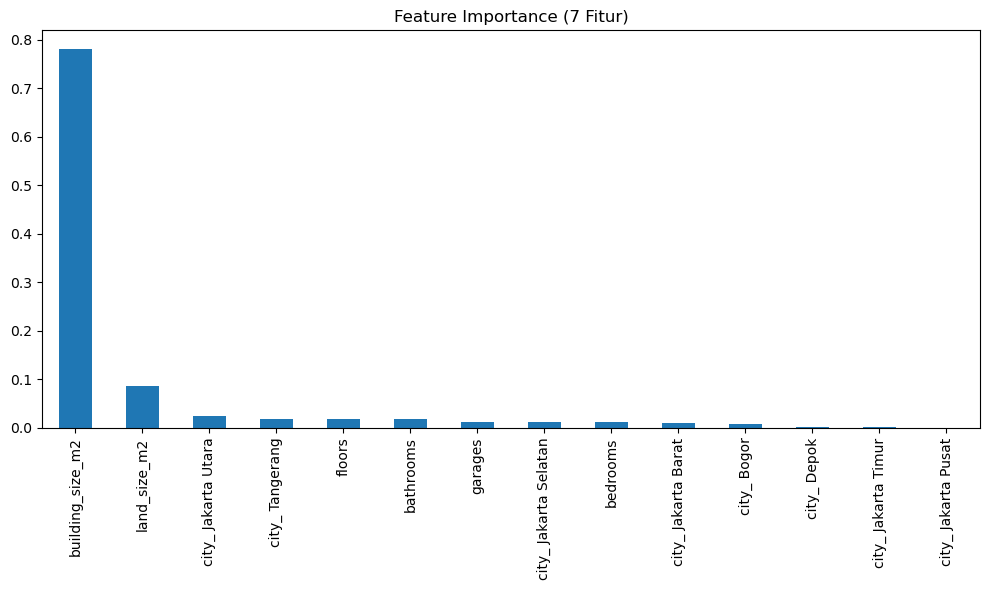

In [22]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Feature Importance (7 Fitur)")
plt.tight_layout()
plt.show()


## 15. Actual vs Predicted

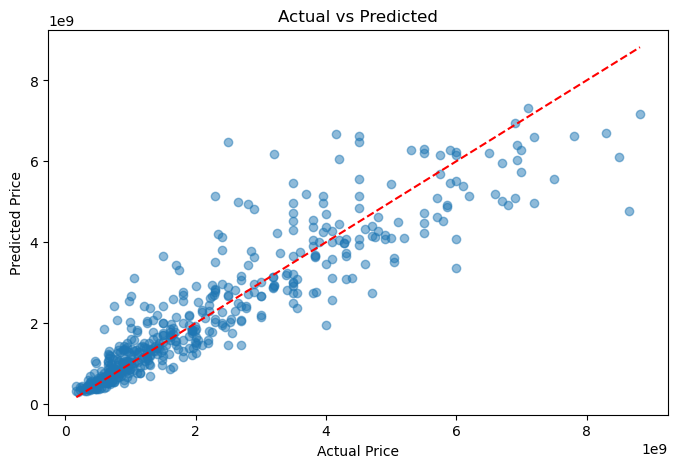

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


## 16. Uji Coba Prediksi Manual

Ini bagian penting untuk menjawab masalah kamu: coba ubah nilai-nilai di bawah
(luas tanah, luas bangunan, kamar, dll) dan jalankan ulang cell ini — harga
prediksi SEKARANG seharusnya ikut berubah secara wajar, karena tidak ada lagi
fitur `price_per_m2` yang "membocorkan" jawaban ke model.


In [24]:
def prediksi_harga(land_size_m2, building_size_m2, bedrooms, bathrooms,
                    floors, garages, city):
    fitur_kolom = joblib.load('fitur_model.pkl')
    model_loaded = joblib.load('random_forest_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')

    # buat 1 baris data kosong sesuai kolom fitur hasil training
    data_baru = pd.DataFrame(np.zeros((1, len(fitur_kolom))), columns=fitur_kolom)

    data_baru.loc[0, 'land_size_m2'] = land_size_m2
    data_baru.loc[0, 'building_size_m2'] = building_size_m2
    data_baru.loc[0, 'bedrooms'] = bedrooms
    data_baru.loc[0, 'bathrooms'] = bathrooms
    data_baru.loc[0, 'floors'] = floors
    data_baru.loc[0, 'garages'] = garages

    kolom_city = f'city_{city}'
    if kolom_city in data_baru.columns:
        data_baru.loc[0, kolom_city] = 1
    # jika city == kategori yang di-drop (drop_first=True), semua kolom city_* tetap 0 -> itu wajar

    data_scaled = scaler_loaded.transform(data_baru)
    harga = model_loaded.predict(data_scaled)[0]
    return harga

# --- Contoh 1 ---
harga1 = prediksi_harga(
    land_size_m2=100, building_size_m2=80, bedrooms=2, bathrooms=1,
    floors=1, garages=1, city='Bekasi'
)
print(f"Prediksi 1 (rumah kecil): Rp {harga1:,.0f}")

# --- Contoh 2: fitur diperbesar ---
harga2 = prediksi_harga(
    land_size_m2=300, building_size_m2=250, bedrooms=5, bathrooms=4,
    floors=2, garages=2, city='Bekasi'
)
print(f"Prediksi 2 (rumah besar) : Rp {harga2:,.0f}")

print(f"\nSelisih: Rp {harga2 - harga1:,.0f}")
print("Kalau selisihnya signifikan dan masuk akal (bukan Rp 0 atau nyaris sama), berarti model sudah benar merespons perubahan fitur.")


Prediksi 1 (rumah kecil): Rp 893,966,237
Prediksi 2 (rumah besar) : Rp 3,893,895,203

Selisih: Rp 2,999,928,966
Kalau selisihnya signifikan dan masuk akal (bukan Rp 0 atau nyaris sama), berarti model sudah benar merespons perubahan fitur.


In [25]:
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

MAE  : 478555537.9766672
RMSE : 747541519.1402817
R2   : 0.8322885373148021
